# Interpretabilidad de modelos finales con SHAP y ALE
La salida explicada es siempre la **probabilidad final de la clase positiva** `claseSdDown`.

In [2]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from PyALE import ale
from scipy.stats import gaussian_kde
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(777)
shap.initjs()

In [40]:
ROOT = Path.cwd().resolve()
MODELS_DIR = ROOT / "Modelos"
CACHE_DIR = ROOT / "CACHE" / "interpretabilidad"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

POSITIVE_LABEL = "claseSdDown"
NUM_COLS = ["EDADmadre", "TALLAmadre", "PESOmadre"]

# Por defecto se explican todas las observaciones.
SHAP_EXPLAIN_ROWS = None
SHAP_BACKGROUND_SIZE = 120
SHAP_MAX_EVALS_FACTOR = 2
TOP_ALE_FEATURES = 6
ALE_GRID_SIZE = 20
ALE_INCLUDE_CI = True
ALE2D_GRID_SIZE = 12
ALE2D_CORR_THRESHOLD = 0.7
ALE2D_MAX_PAIRS = 3
ALE2D_CLASS_DENSITY_PROBS = [0.9]
ALE2D_CONTROL_COLOR = "#355070"
ALE2D_CASE_COLOR = "#9a031e"

In [21]:
MODEL_SPECS = {
    "SVC_1T": {"path": MODELS_DIR / "best_1T.joblib", "dataset": "T1"},
    "RF_2T": {"path": MODELS_DIR / "best_2T.joblib", "dataset": "T2"},
    "logreg_12T": {"path": MODELS_DIR / "best_12T.joblib", "dataset": "T12"},
    "STACK": {"path": MODELS_DIR / "STACK.joblib", "dataset": "T12"},
    "STACK_pt": {"path": MODELS_DIR / "STACK_pt.joblib", "dataset": "T12"},
}

## Datos y preprocesado

Se replica el preprocesado del notebook principal:

- unión con `Madre`
- estandarización de `EDADmadre`, `TALLAmadre` y `PESOmadre`
- salida como `DataFrame` para conservar nombres de variables

In [22]:
Madre = pd.read_csv(ROOT / "BBDD" / "Madre.csv", index_col=0)
T1 = pd.read_csv(ROOT / "BBDD" / "T1_MoM.csv", index_col=0)
T2 = pd.read_csv(ROOT / "BBDD" / "T2_MoM.csv", index_col=0)

T1_X = T1.join(Madre.drop(columns="CLASE"), how="left")
T1_y = Madre.loc[T1.index, "CLASE"]

T2_X = T2.join(Madre.drop(columns="CLASE"), how="left")
T2_y = Madre.loc[T2.index, "CLASE"]

T12_X = T1.join(T2, how="inner").join(Madre.drop(columns="CLASE"), how="left")
T12_y = Madre.loc[T12_X.index, "CLASE"]


def build_preprocessor():
    return ColumnTransformer(
        [("standard", StandardScaler(), NUM_COLS)],
        verbose_feature_names_out=False,
        remainder="passthrough",
    ).set_output(transform="pandas")


X_T1 = build_preprocessor().fit_transform(T1_X)
X_T2 = build_preprocessor().fit_transform(T2_X)
X_T12 = build_preprocessor().fit_transform(T12_X)

DATASETS = {
    "T1": {"X": X_T1, "y": T1_y},
    "T2": {"X": X_T2, "y": T2_y},
    "T12": {"X": X_T12, "y": T12_y},
}

for name, data in DATASETS.items():
    print(name, data["X"].shape, data["y"].shape)

T1 (2291, 6) (2291,)
T2 (1667, 15) (1667,)
T12 (1628, 18) (1628,)


In [23]:
MODELS = {
    name: joblib.load(spec["path"])
    for name, spec in MODEL_SPECS.items()
}

for name, model in MODELS.items():
    print(f"{name}: {type(model).__name__}")

SVC_1T: CalibratedClassifierCV
RF_2T: CalibratedClassifierCV
logreg_12T: CalibratedClassifierCV
STACK: StackingClassifier
STACK_pt: StackingClassifier


## Helpers

In [33]:

class PositiveProbabilityModel:
    def __init__(self, model, columns):
        self.model = model
        self.columns = list(columns)
        self.positive_label = positive_label

    def __call__(self, X):
        #predict_proba
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)
        proba=self.model.predict_proba(X)[:,1]
        return proba




def correlation_pairs(X, candidate_features=None, threshold=ALE2D_CORR_THRESHOLD, max_pairs=ALE2D_MAX_PAIRS):
    """
    Identifica si algunas características tienen suficiente correlación como para mostrarse el ALE 2D,
    candidate_features: si se especifica, se restringe a esas características.
    threshold: punto de corte para considerar una correlación alta
    max_pairs: máximo de parejas deseados.
    """
    corr = X.corr(numeric_only=True).abs()
    if candidate_features is not None:
        features = [feature for feature in candidate_features if feature in corr.index]
        corr = corr.loc[features, features]
        
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) #triangular superior
    pairs = (
        upper.stack()
        .rename("abs_corr")
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    )
    pairs = pairs.loc[pairs["abs_corr"] >= threshold].head(max_pairs).reset_index(drop=True) #Top parejas filtradas
    return pairs


def subset_for_explanation(X, explain_rows=SHAP_EXPLAIN_ROWS):
    #si se especifican las filas, para ahorrar cómputo.
    if explain_rows is None:
        return X.copy()
    return X.iloc[:explain_rows].copy()


def build_shap_explainer(model, X, background_size=SHAP_BACKGROUND_SIZE):
    background = shap.sample(X, min(background_size, len(X)), random_state=777) #muestra representativa
    wrapped_model = PositiveProbabilityModel(model, columns=X.columns)
    masker = shap.maskers.Independent(background)
    explainer = shap.Explainer(
        wrapped_model,
        masker=masker,
        algorithm="permutation",
    )
    return explainer, background


def compute_shap_explanation(model_name, model, X, force=False):
    cache_path = CACHE_DIR / f"shap_{model_name}.joblib"
    if cache_path.exists() and not force:
        return joblib.load(cache_path)

    X_explain = subset_for_explanation(X)
    explainer, background = build_shap_explainer(model, X)
    explanation = explainer(
        X_explain,
        max_evals=SHAP_MAX_EVALS_FACTOR * X.shape[1] + 1,
    )
    payload = {
        "explanation": explanation,
        "background": background,
    }
    joblib.dump(payload, cache_path)
    return payload


def shap_importance(explanation):
    #Shap medio absoluto, para comparar variables
    mean_abs = explanation.abs.mean(0)
    return pd.Series(
        mean_abs.values,
        index=mean_abs.feature_names,
        name="mean_abs_shap",
    ).sort_values(ascending=False)


def center_ale_dataframe(df, effect_col="eff", weight_col="size"):
    #Centra en 0 según la mediana, para evaluar los desvíos
    centered = df.copy()
    weights = centered[weight_col].fillna(0).to_numpy(dtype=float)
    effects = centered[effect_col].to_numpy(dtype=float)
    valid = weights > 0
    if valid.any():
        shift = np.average(effects[valid], weights=weights[valid])
    else:
        shift = effects.mean()

    centered["eff_centered"] = centered[effect_col] - shift
    #Shift para IC
    low_cols = [c for c in centered.columns if "lower" in c.lower()] 
    up_cols = [c for c in centered.columns if "upper" in c.lower()]
    if low_cols and up_cols:
        centered["lower_centered"] = centered[low_cols[0]] - shift
        centered["upper_centered"] = centered[up_cols[0]] - shift
    return centered


def compute_ale_results(model_name, model, X, features, force=False):
    cache_path = CACHE_DIR / f"ale_{model_name}.joblib"
    if cache_path.exists() and not force:
        cached = joblib.load(cache_path)
    else:
        cached = {}

    missing = [feature for feature in features if feature not in cached]
    if missing:
        wrapped_model = PositiveProbabilityModel(model, columns=X.columns)
        for feature in missing:
            result = ale(
                X=X,
                model=wrapped_model,
                feature=[feature],
                grid_size=ALE_GRID_SIZE,
                include_CI=ALE_INCLUDE_CI,
                plot=False,
            )
            cached[feature] = center_ale_dataframe(result)
        joblib.dump(cached, cache_path)
    return {feature: cached[feature] for feature in features}


def center_ale2d_dataframe(df):
    centered = df.copy()
    values = centered.to_numpy(dtype=float)
    shift = np.nanmean(values)
    centered.iloc[:, :] = values - shift
    return centered


def compute_ale2d_results(model_name, model, X, pairs_df, force=False):
    cache_path = CACHE_DIR / f"ale2d_{model_name}.joblib"
    if cache_path.exists() and not force:
        cached = joblib.load(cache_path)
    else:
        cached = {}

    wrapped_model = PositiveProbabilityModel(model, columns=X.columns)
    pair_keys = []
    for _, row in pairs_df.iterrows():
        f1, f2 = row["feature_1"], row["feature_2"]
        key = f"{f1}__{f2}"
        pair_keys.append((key, f1, f2))
        if force or key not in cached:
            result = ale(
                X=X,
                model=wrapped_model,
                feature=[f1, f2],
                grid_size=ALE2D_GRID_SIZE,
                include_CI=False,
                plot=False,
                contour=False,
            )
            cached[key] = center_ale2d_dataframe(result)

    joblib.dump(cached, cache_path)
    return {key: {"features": (f1, f2), "data": cached[key]} for key, f1, f2 in pair_keys}


def plot_shap_summary(model_name, explanation, max_display=15):
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(explanation, max_display=max_display, show=False)
    plt.title(f"SHAP summary plot - {model_name}", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_ale_grid(model_name, ale_results, ncols=3):
    features = list(ale_results.keys())
    n = len(features)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    y_values = []
    for feature in features:
        df = ale_results[feature]
        y_values.append(df["eff_centered"].to_numpy(dtype=float))
        if {"lower_centered", "upper_centered"}.issubset(df.columns):
            y_values.append(df["lower_centered"].to_numpy(dtype=float))
            y_values.append(df["upper_centered"].to_numpy(dtype=float))

    y_concat = np.concatenate(y_values)
    y_abs_max = np.nanmax(np.abs(y_concat))
    y_abs_max = 1.0 if not np.isfinite(y_abs_max) or y_abs_max == 0 else y_abs_max
    y_margin = 0.08 * y_abs_max
    y_limits = (-y_abs_max - y_margin, y_abs_max + y_margin)

    for ax, feature in zip(axes, features):
        df = ale_results[feature]
        x = pd.Index(df.index).astype(float)
        ax.plot(x, df["eff_centered"].to_numpy(dtype=float), lw=2, color="#0a9396")

        if {"lower_centered", "upper_centered"}.issubset(df.columns):
            ax.fill_between(
                x,
                df["lower_centered"].to_numpy(dtype=float),
                df["upper_centered"].to_numpy(dtype=float),
                alpha=0.22,
                color="#94d2bd",
            )

        ax.axhline(0, color="black", lw=1, ls="--")
        ax.set_ylim(y_limits)
        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel("ALE")
        ax.grid(alpha=0.3)

    for ax in axes[len(features):]:
        ax.axis("off")

    fig.suptitle(f"ALE 1D  - {model_name}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def kde_probability_levels(density_grid, probs):
    #Contornos en ALE2D
    probs = np.asarray(probs, dtype=float)
    flat = np.asarray(density_grid, dtype=float).ravel()
    flat = flat[np.isfinite(flat)]
    if flat.size == 0:
        return np.array([]), np.array([])

    sorted_density = np.sort(flat)[::-1]
    cumulative = np.cumsum(sorted_density)
    cumulative = cumulative / cumulative[-1]

    raw_levels = []
    for prob in probs:
        idx = np.searchsorted(cumulative, prob, side="left")
        idx = min(idx, len(sorted_density) - 1)
        raw_levels.append(sorted_density[idx])

    level_prob_pairs = sorted(zip(raw_levels, probs), key=lambda pair: pair[0])
    unique_pairs = []
    for level, prob in level_prob_pairs:
        if not unique_pairs or not np.isclose(level, unique_pairs[-1][0]):
            unique_pairs.append((level, prob))

    levels = np.array([pair[0] for pair in unique_pairs], dtype=float)
    kept_probs = np.array([pair[1] for pair in unique_pairs], dtype=float)
    return levels, kept_probs


def add_class_density_contours(ax, x_grid, y_grid, density_data, color, prefix, probs):
    if len(density_data) <= 5:
        return

    kde = gaussian_kde(density_data.to_numpy().T)
    density_grid = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
    density_levels, kept_probs = kde_probability_levels(density_grid, probs)

    if len(density_levels) == 0:
        return

    density_contour = ax.contour(
        x_grid,
        y_grid,
        density_grid,
        levels=density_levels,
        colors=color,
        linewidths=1.2,
        alpha=0.95,
    )
    fmt = {
        level: f"{prefix} {int(round(prob * 100))}%"
        for level, prob in zip(density_contour.levels, kept_probs)
    }
    ax.clabel(density_contour, density_contour.levels, inline=True, fmt=fmt, fontsize=8)


def plot_ale2d_grid(model_name, ale2d_results, X, y, ncols=2):
    if not ale2d_results:
        print(f"No se detectaron pares con correlación >= {ALE2D_CORR_THRESHOLD} para {model_name}.")
        return

    items = list(ale2d_results.items())
    n = len(items)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    z_values = [payload["data"].to_numpy(dtype=float) for _, payload in items]
    z_concat = np.concatenate([z.ravel() for z in z_values])
    z_abs_max = np.nanmax(np.abs(z_concat))
    z_abs_max = 1.0 if not np.isfinite(z_abs_max) or z_abs_max == 0 else z_abs_max
    levels = np.linspace(-z_abs_max, z_abs_max, 21)

    y_series = pd.Series(y, index=X.index)
    mask_case = y_series == POSITIVE_LABEL
    mask_control = ~mask_case

    for ax, (key, payload) in zip(axes, items):
        f1, f2 = payload["features"]
        df = payload["data"]
        x = np.asarray(df.columns, dtype=float)
        y_axis = np.asarray(df.index, dtype=float)
        z = df.to_numpy(dtype=float)
        xx, yy = np.meshgrid(x, y_axis)

        contour = ax.contourf(xx, yy, z, levels=levels, cmap="coolwarm", extend="both")

        control_data = X.loc[mask_control, [f1, f2]].dropna()
        case_data = X.loc[mask_case, [f1, f2]].dropna()
        add_class_density_contours(
            ax,
            xx,
            yy,
            control_data,
            color=ALE2D_CONTROL_COLOR,
            prefix="Ctrl",
            probs=ALE2D_CLASS_DENSITY_PROBS,
        )
        add_class_density_contours(
            ax,
            xx,
            yy,
            case_data,
            color=ALE2D_CASE_COLOR,
            prefix="Caso",
            probs=ALE2D_CLASS_DENSITY_PROBS,
        )

        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y_axis.min(), y_axis.max())
        ax.set_title(f"{f1} vs {f2}")
        ax.set_xlabel(f1)
        ax.set_ylabel(f2)
        fig.colorbar(contour, ax=ax)

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.suptitle(
        f"ALE 2D interacción - {model_name}",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

## Rutina de interpretación por modelo

Flujo:

1. calcular explicación SHAP
2. mostrar ranking global por `mean(|SHAP|)`
3. dibujar el summary plot de SHAP
4. seleccionar variables top y calcular ALE 1D centradas en cero ALE 2D para interacciones relevantes

In [25]:
def interpret_model(
    model_name,
    force_shap=False,
    force_ale=False,
    top_ale_features=TOP_ALE_FEATURES,
    shap_max_display=15,
):
    dataset_name = MODEL_SPECS[model_name]["dataset"]
    X = DATASETS[dataset_name]["X"]
    y = DATASETS[dataset_name]["y"]
    model = MODELS[model_name]

    print(f"\n{'=' * 80}")
    print(f"Modelo: {model_name}")
    print(f"Dataset: {dataset_name}")
    print(f"N observaciones: {len(X)}")
    print(f"N variables: {X.shape[1]}")

    shap_payload = compute_shap_explanation(
        model_name=model_name,
        model=model,
        X=X,
        force=force_shap,
    )
    explanation = shap_payload["explanation"]
    importance = shap_importance(explanation)
    display(importance.to_frame().head(top_ale_features))

    plot_shap_summary(model_name, explanation, max_display=shap_max_display)

    selected_features = importance.head(top_ale_features).index.tolist()
    ale_results = compute_ale_results(
        model_name=model_name,
        model=model,
        X=X,
        features=selected_features,
        force=force_ale,
    )
    plot_ale_grid(model_name, ale_results)

    corr_pairs = correlation_pairs(
        X,
        candidate_features=selected_features,
        threshold=ALE2D_CORR_THRESHOLD,
        max_pairs=ALE2D_MAX_PAIRS,
    )
    if len(corr_pairs):
        print("\nPares seleccionados para ALE 2D según correlación absoluta:")
        display(corr_pairs)
        ale2d_results = compute_ale2d_results(
            model_name=model_name,
            model=model,
            X=X,
            pairs_df=corr_pairs,
            force=force_ale,
        )
        plot_ale2d_grid(model_name, ale2d_results, X=X, y=y)
    else:
        ale2d_results = {}
        print(f"\nNo hay pares con correlaci?n absoluta >= {ALE2D_CORR_THRESHOLD} entre las variables top.")

    return {
        "dataset": dataset_name,
        "X": X,
        "y": y,
        "model": model,
        "explanation": explanation,
        "importance": importance,
        "ale_results": ale_results,
        "ale2d_results": ale2d_results,
        "corr_pairs": corr_pairs,
        "selected_features": selected_features,
    }

## Ejecución individual por modelo


Modelo: SVC_1T
Dataset: T1
N observaciones: 2291
N variables: 6


,mean_abs_shap
PAPPA_LMoM,0.029226
sn_LMoM,0.025030
HCG_LMoM,0.019439
EDADmadre,0.015686
PESOmadre,0.004429
TALLAmadre,0.001605


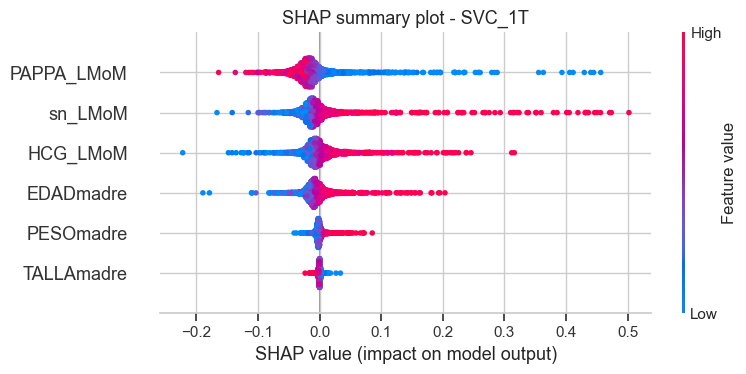

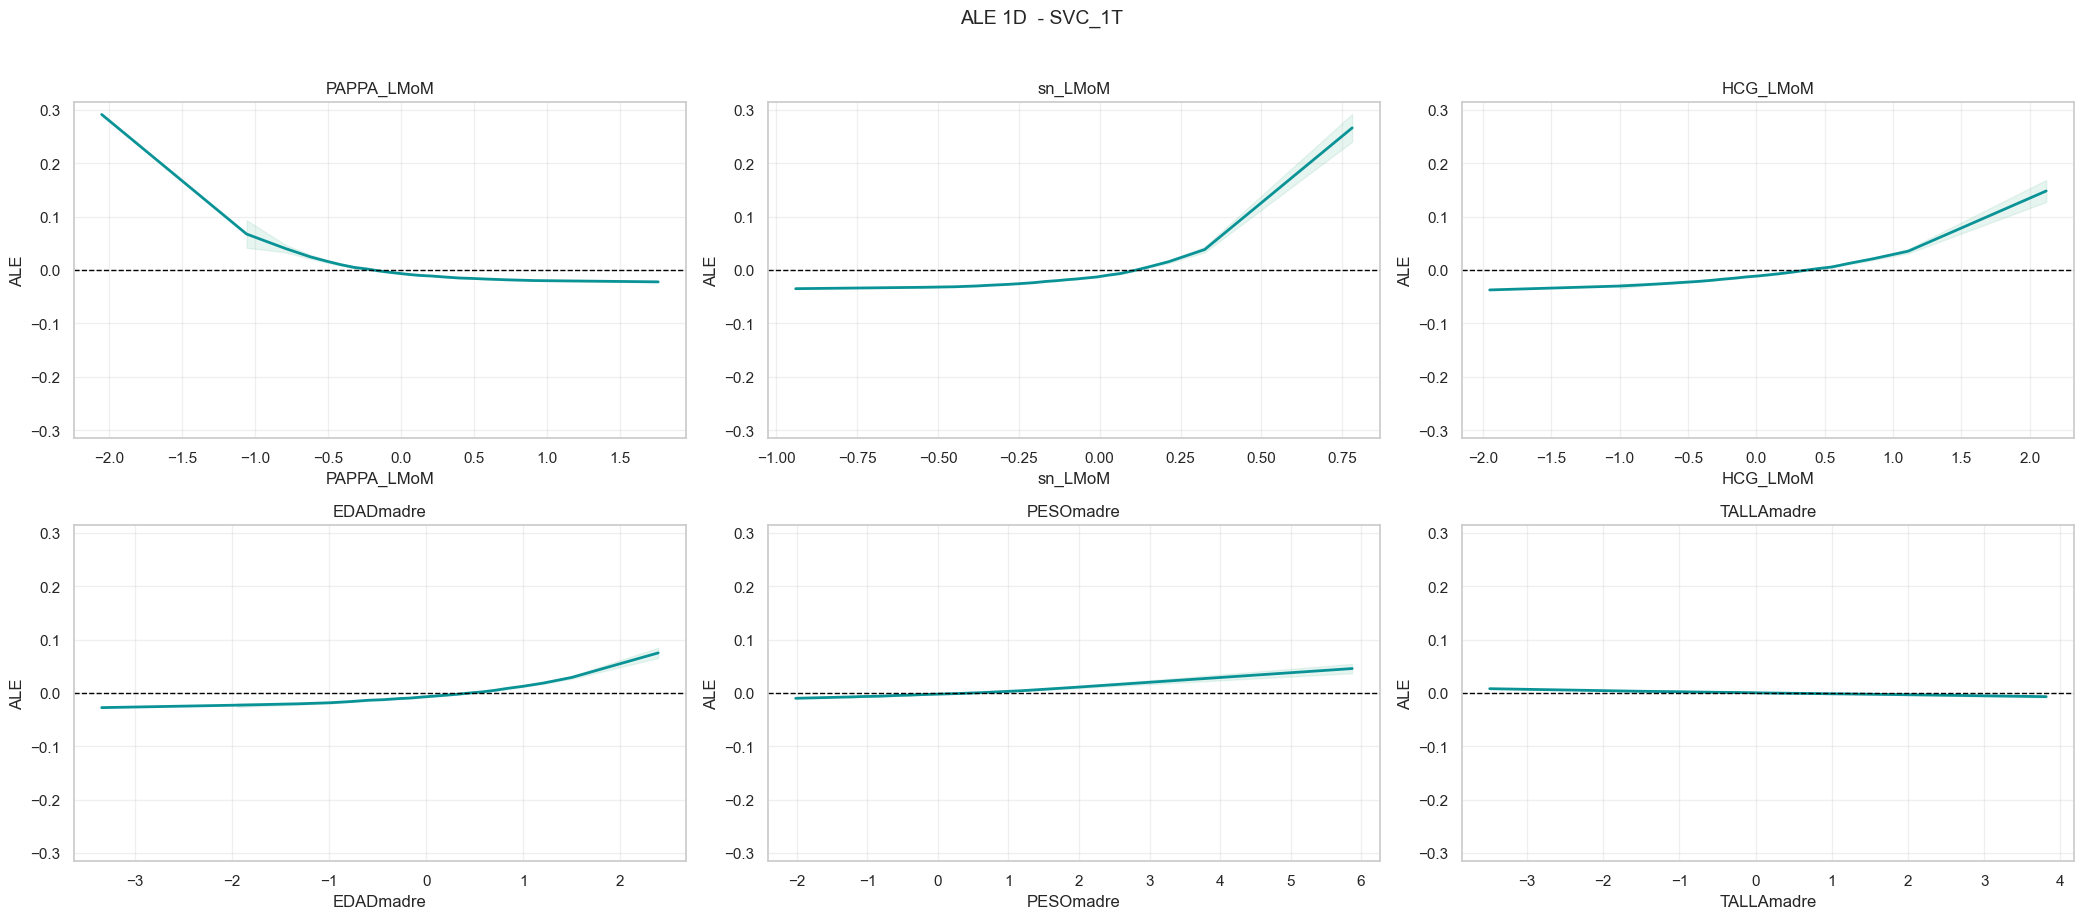


No hay pares con correlaci?n absoluta >= 0.75 entre las variables top.


In [27]:
result_best_1T = interpret_model('SVC_1T')


Modelo: RF_2T
Dataset: T2
N observaciones: 1667
N variables: 15


,mean_abs_shap
LF,0.032002
PER_CEFAL,0.020111
EDADmadre,0.014287
DBP,0.010695
PER_ABDOM,0.006874
mOTR,0.004221


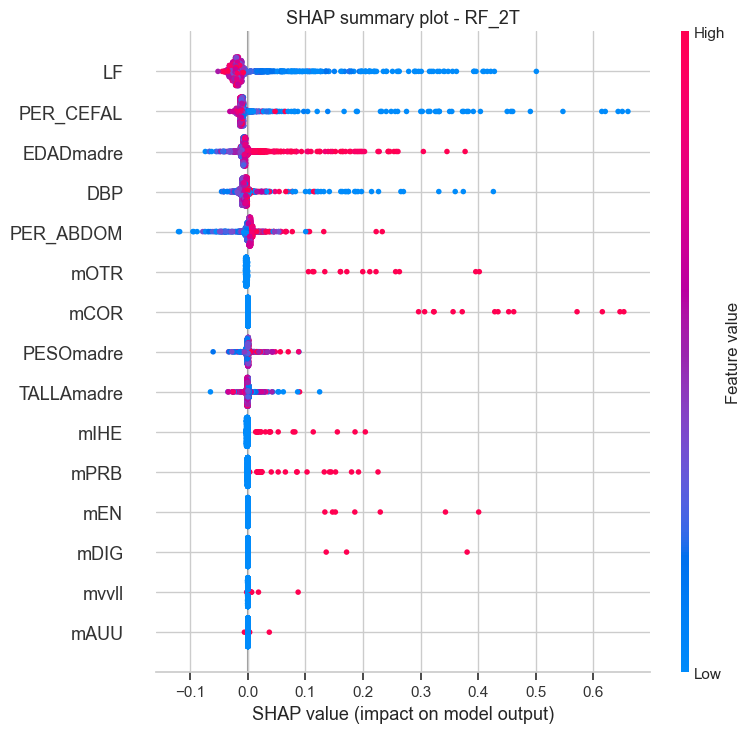

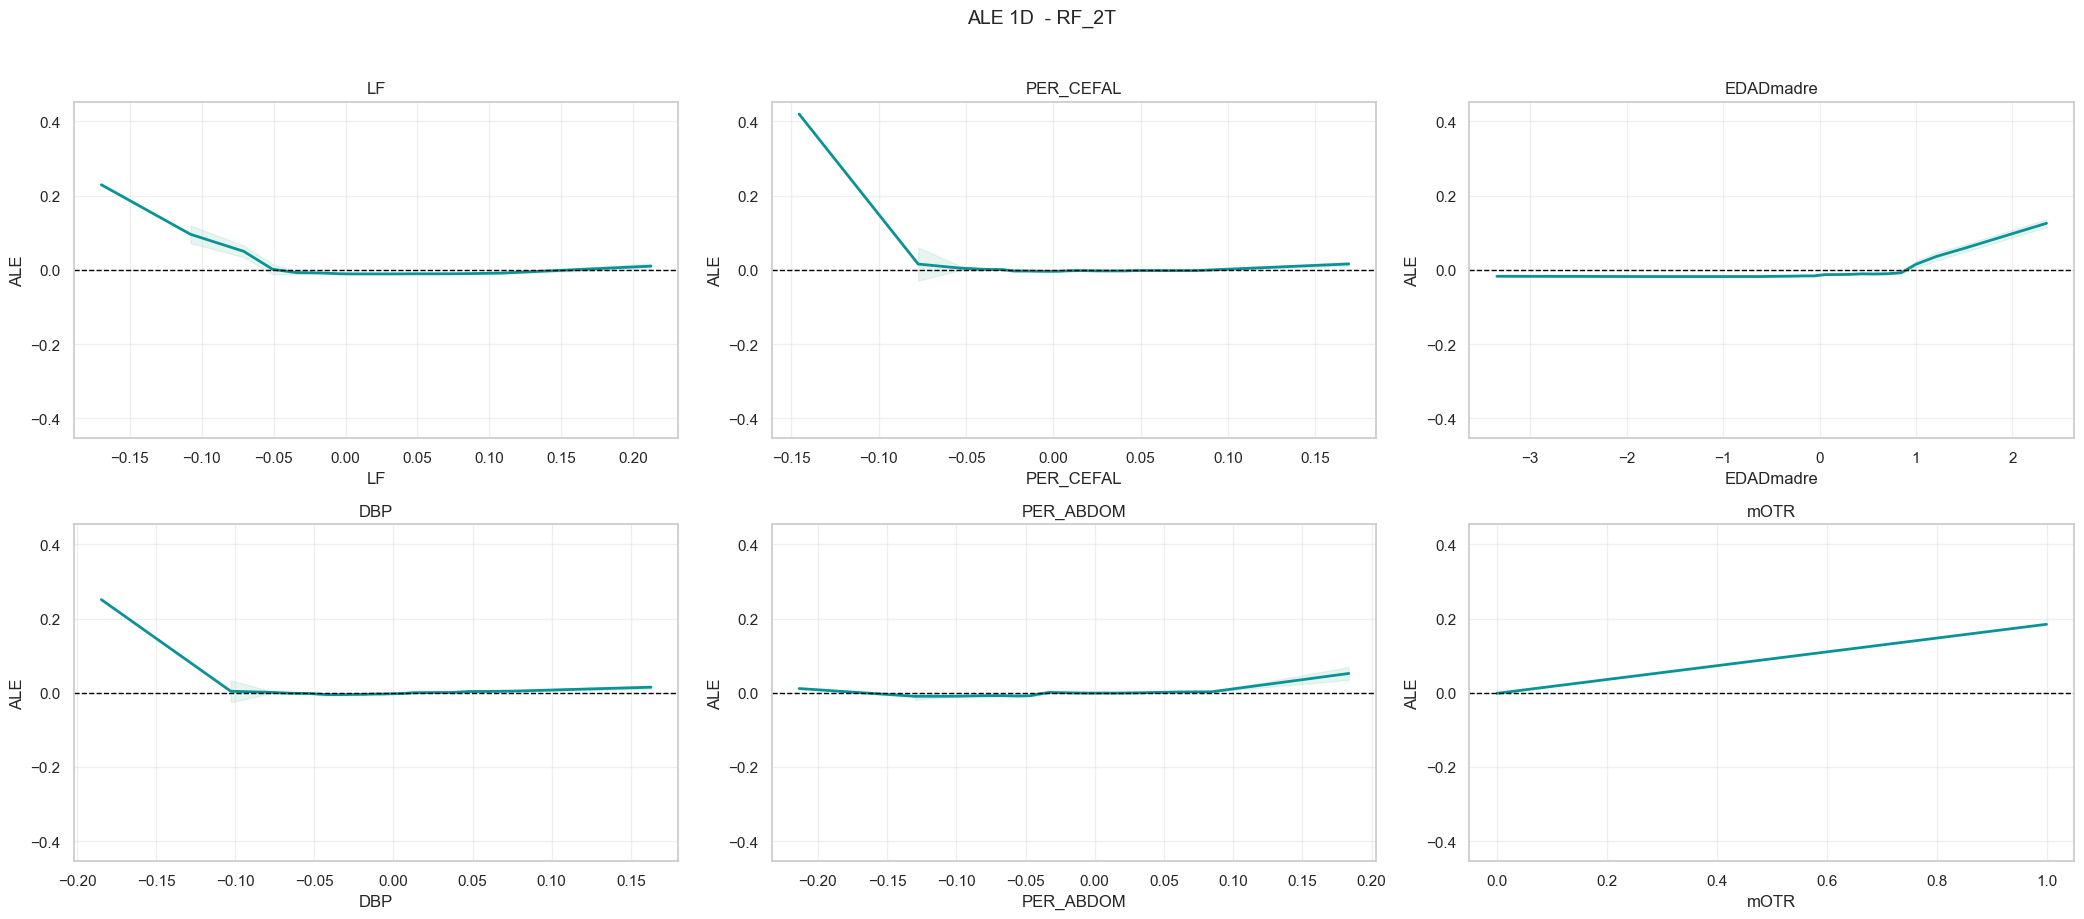


Pares seleccionados para ALE 2D según correlación absoluta:


,feature_1,feature_2,abs_corr
0,PER_CEFAL,DBP,0.820281


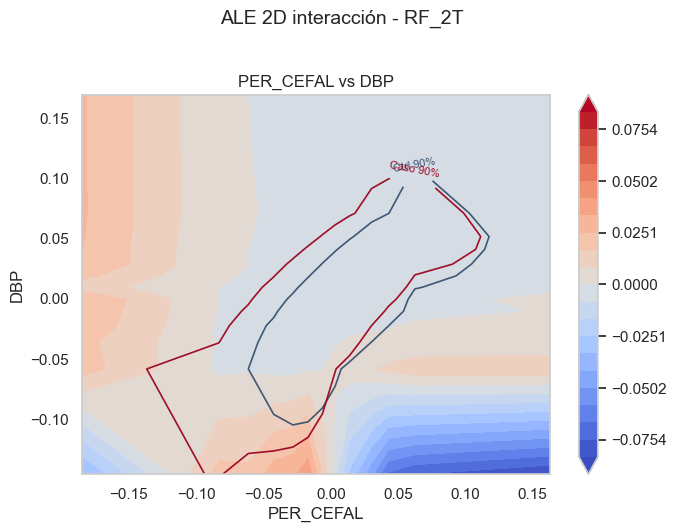

In [34]:
result_best_2T = interpret_model('RF_2T')


Modelo: logreg_12T
Dataset: T12
N observaciones: 1628
N variables: 18


,mean_abs_shap
PAPPA_LMoM,0.022070
sn_LMoM,0.019210
HCG_LMoM,0.014547
EDADmadre,0.011373
LF,0.004534
PER_CEFAL,0.004341


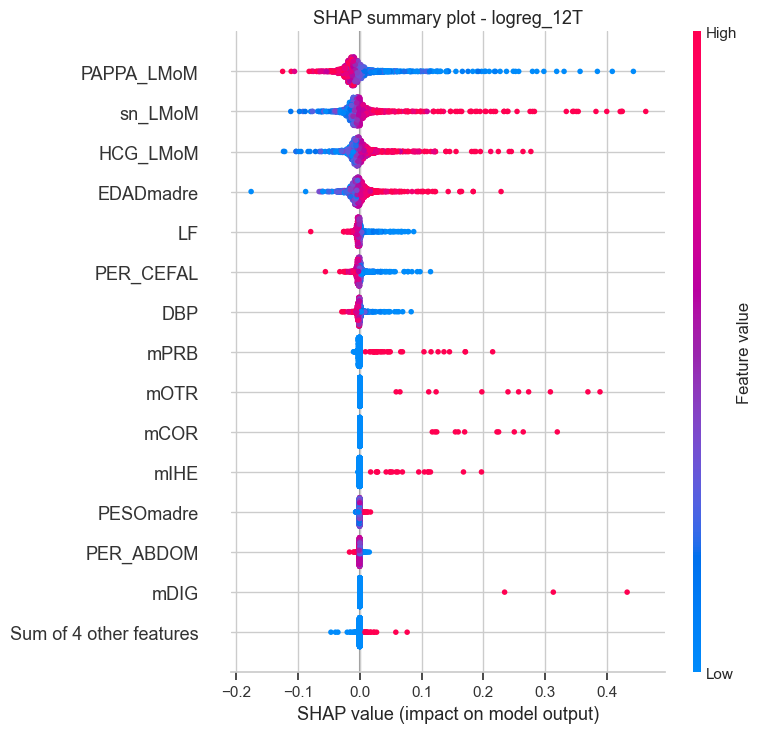

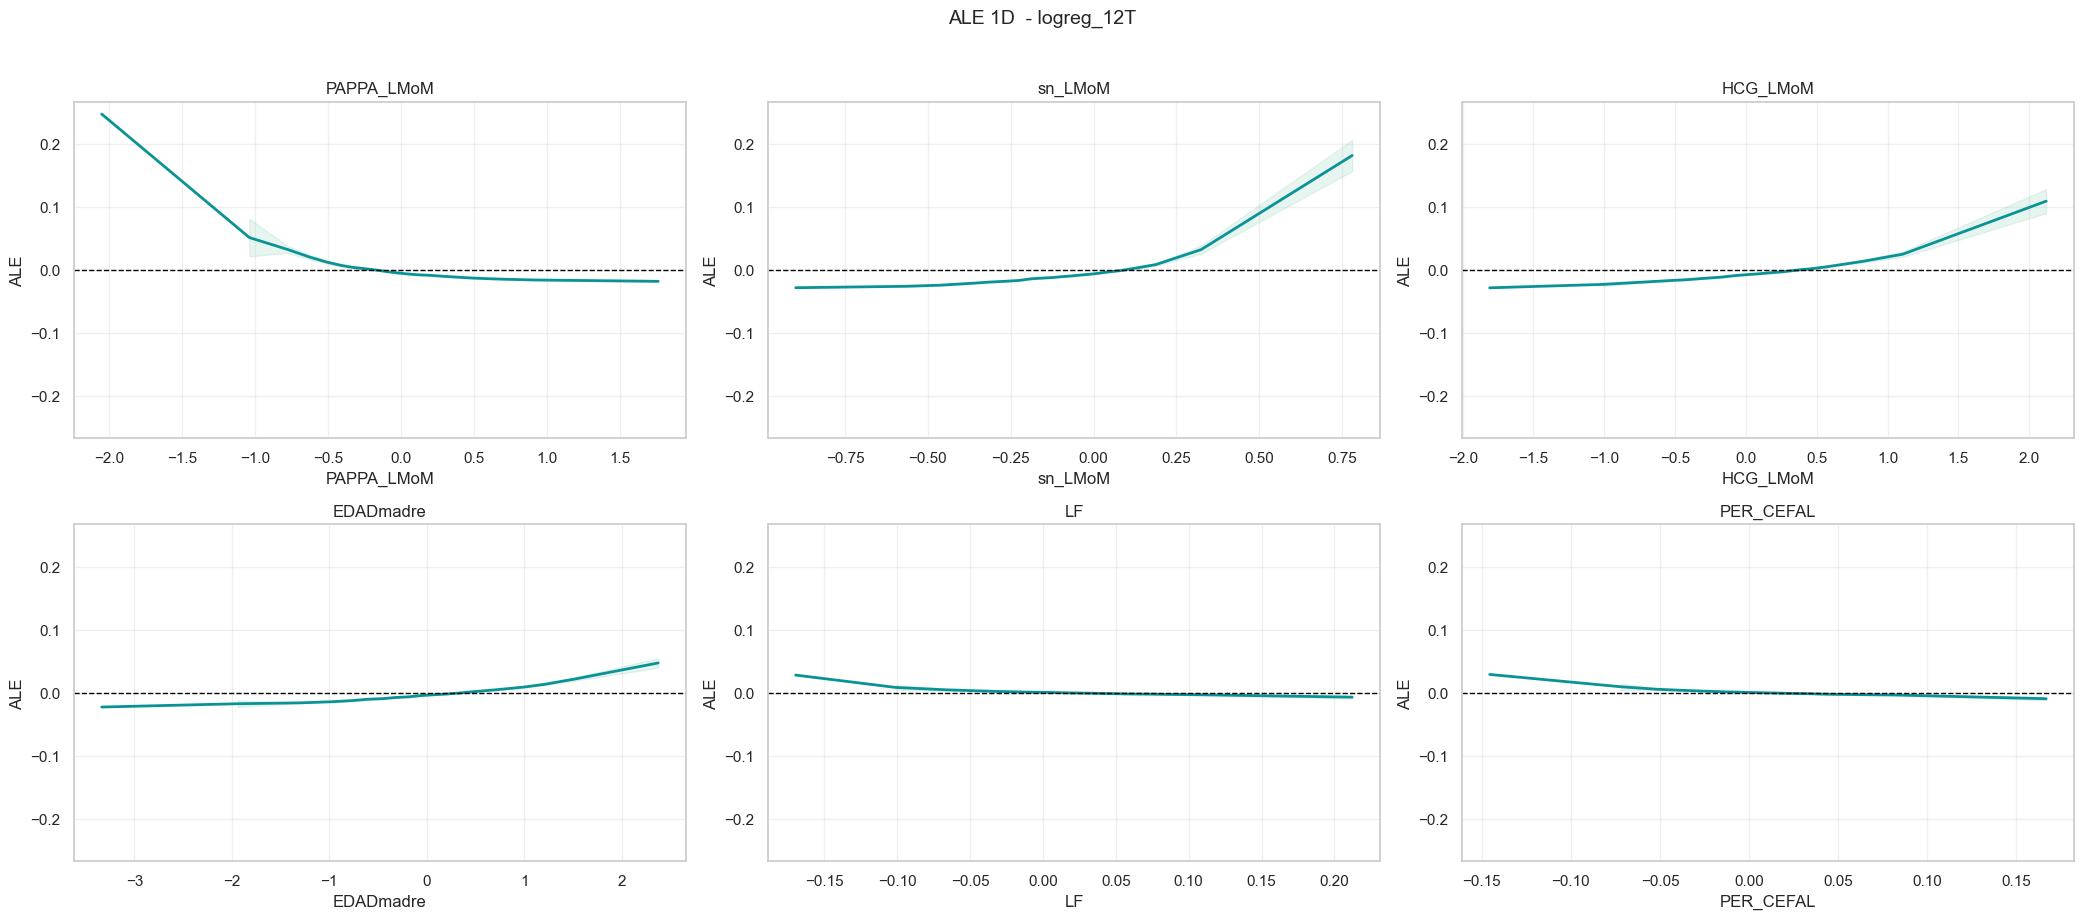


No hay pares con correlaci?n absoluta >= 0.75 entre las variables top.


In [30]:
result_best_12T = interpret_model('logreg_12T')


Modelo: STACK
Dataset: T12
N observaciones: 1628
N variables: 18


,mean_abs_shap
LF,0.009525
sn_LMoM,0.009015
PAPPA_LMoM,0.008210
EDADmadre,0.008100
HCG_LMoM,0.005970
PER_CEFAL,0.005335


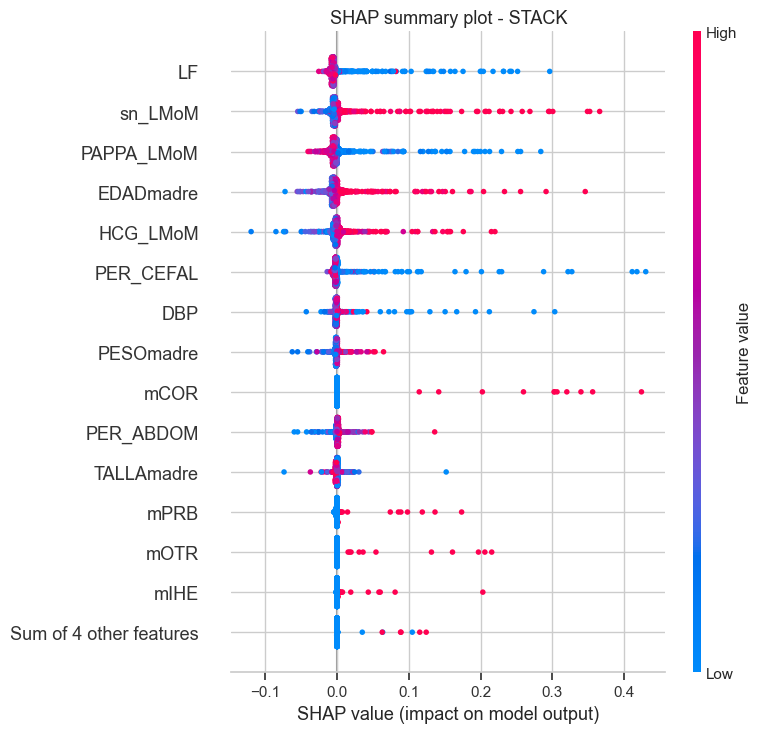

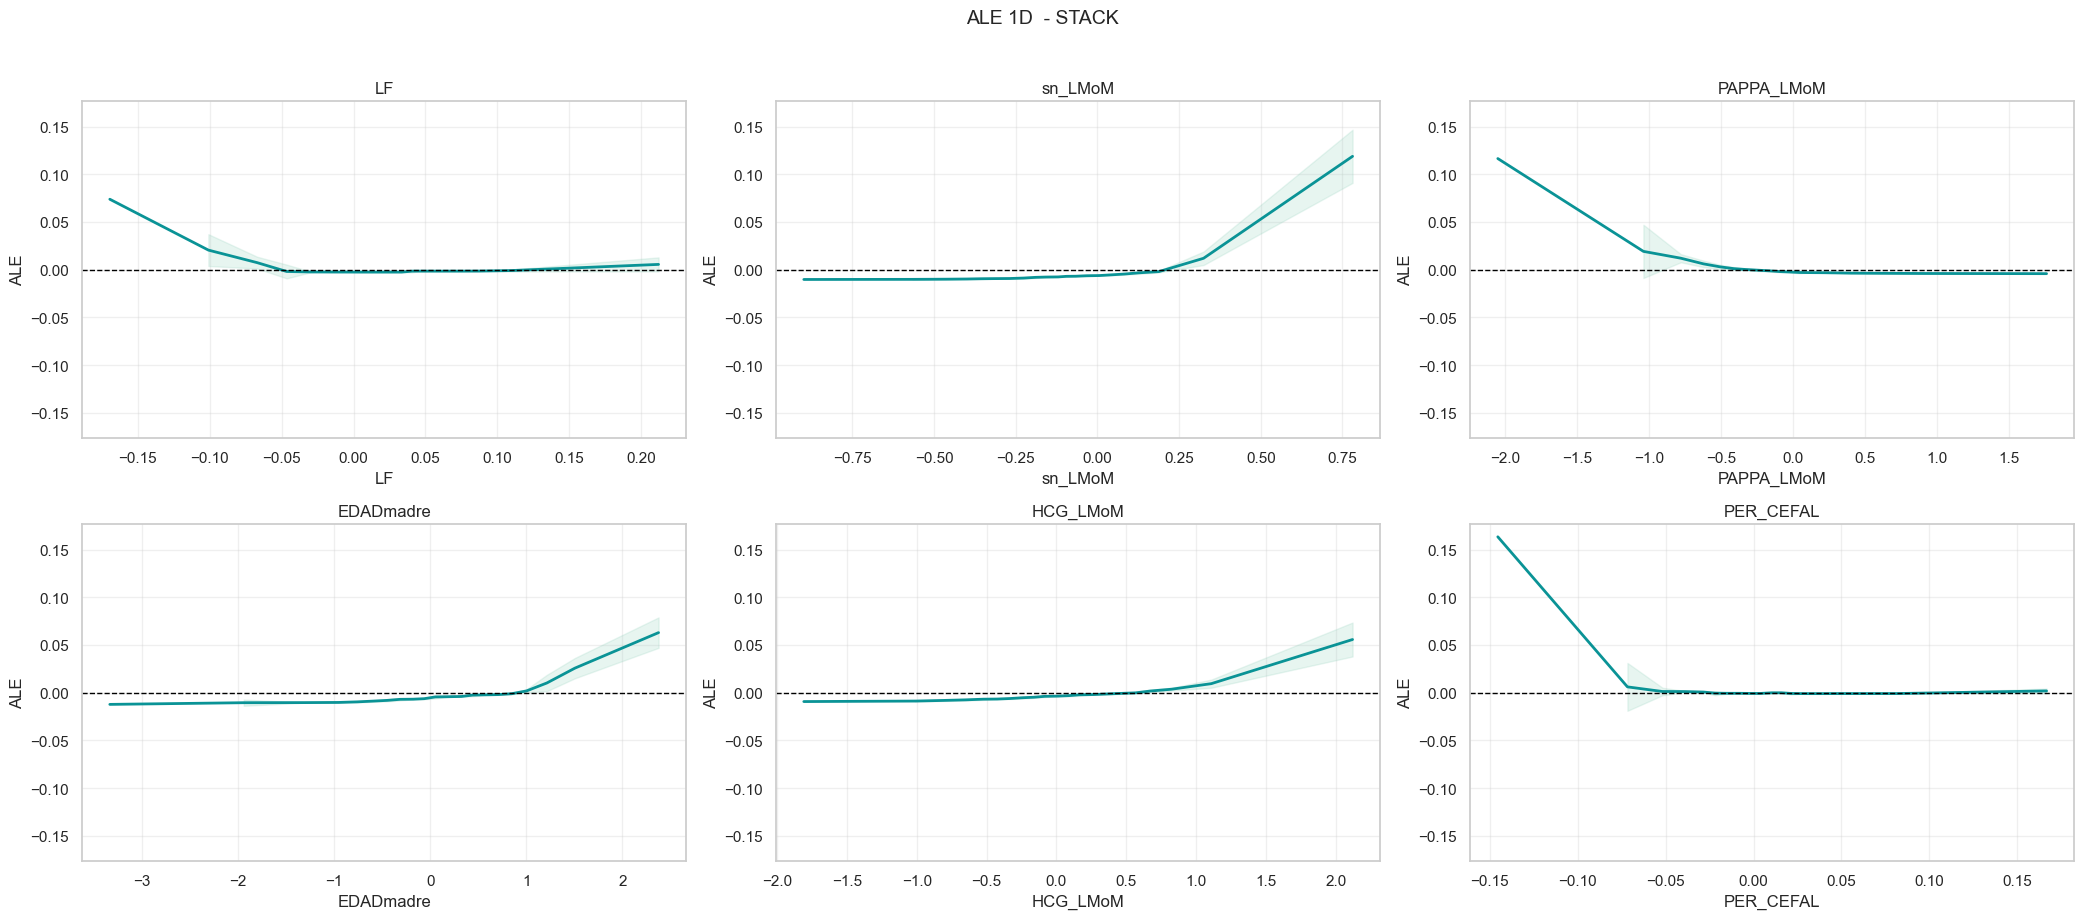


No hay pares con correlaci?n absoluta >= 0.7 entre las variables top.


In [41]:
result_STACK = interpret_model('STACK')


Modelo: STACK_pt
Dataset: T12
N observaciones: 1628
N variables: 18


,mean_abs_shap
PAPPA_LMoM,0.021129
sn_LMoM,0.014972
EDADmadre,0.012402
HCG_LMoM,0.011622
LF,0.006710
PER_CEFAL,0.003698


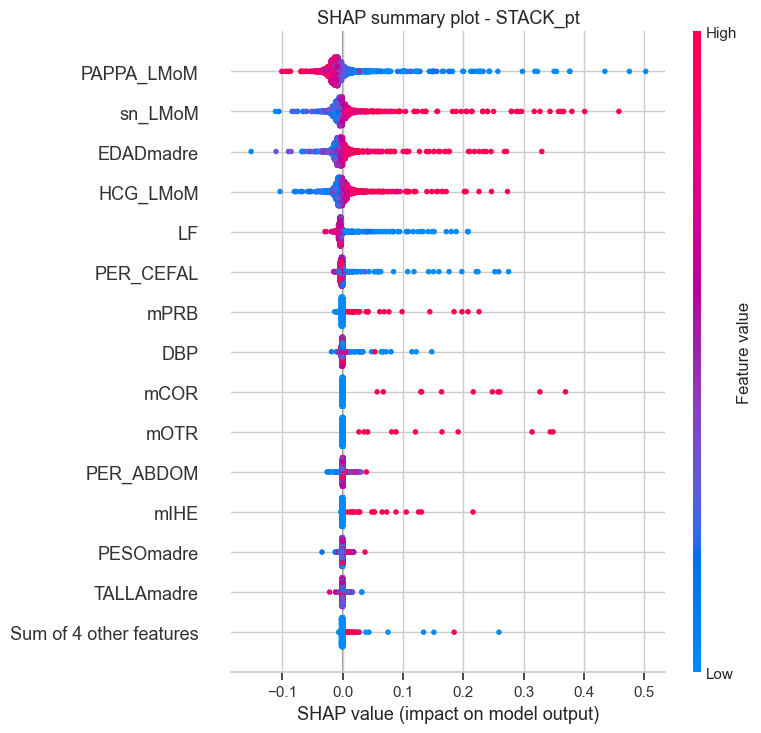

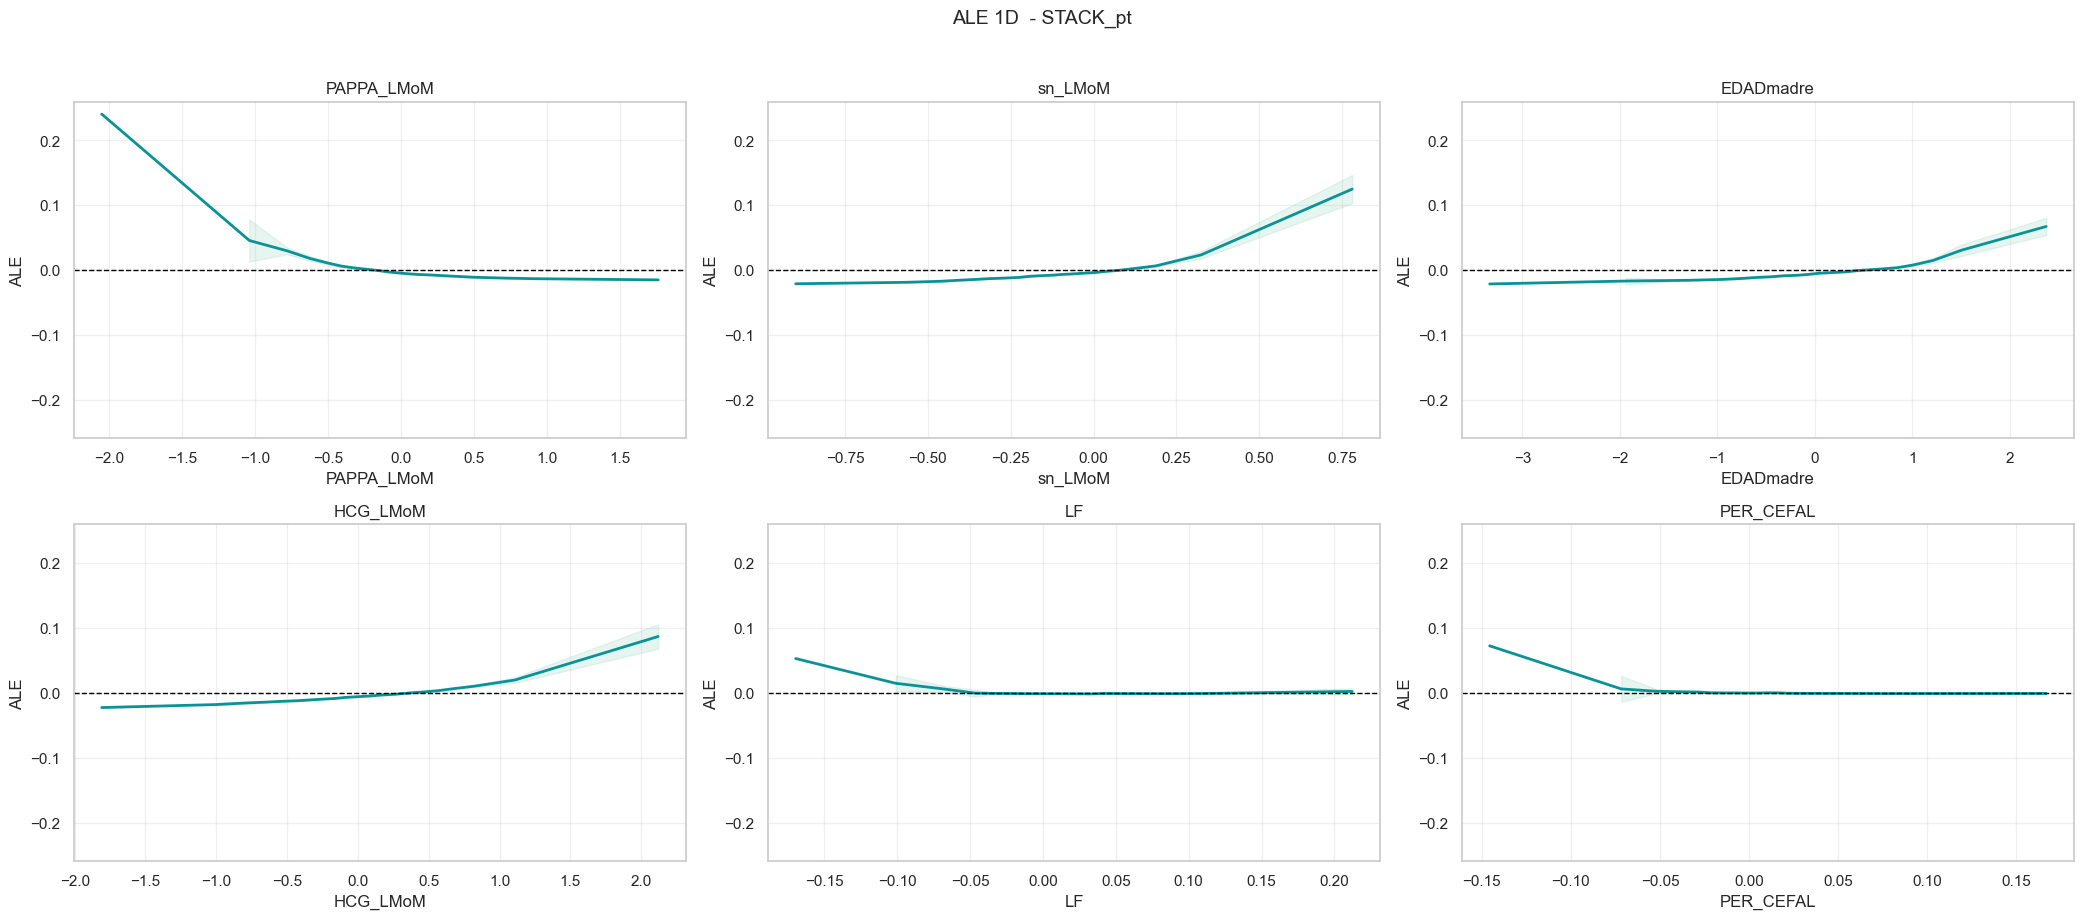


No hay pares con correlaci?n absoluta >= 0.75 entre las variables top.


In [31]:
result_STACK_pt = interpret_model('STACK_pt')